# Patrón Estructural: Adapter — Integración de laboratorio externo

El patrón Adapter permite que dos interfaces incompatibles trabajen juntas, traduciendo la interfaz de una clase (que no se puede o no se quiere modificar) a la interfaz que el cliente espera.

El sistema interno de la clínica espera que cualquier proveedor de exámenes de laboratorio implemente `obtener_resultado(id_paciente) -> dict` con las llaves `paciente`, `examen` y `valor`. La clínica integra un laboratorio externo, `LaboratorioExternoSDK`, cuyo SDK real expone `fetch_report(patient_id)` y devuelve un formato completamente distinto (llaves en inglés, anidado, con el valor como string con unidades).

## Sin patrón Adapter (forma errónea)

El SDK externo no tiene el método que el sistema interno espera, ni devuelve el formato que el sistema interno necesita.

In [5]:
class LaboratorioExternoSDK:
    """SDK de un proveedor externo: no se puede modificar su código."""

    def fetch_report(self, patient_id):
        return {
            "pid": patient_id,
            "report": {"test_name": "Glucosa", "result": "95 mg/dL"},
        }


def imprimir_resultado_laboratorio(proveedor, id_paciente):
    resultado = proveedor.obtener_resultado(id_paciente)
    print(f"Paciente {resultado['paciente']}: {resultado['examen']} = {resultado['valor']}")


laboratorio = LaboratorioExternoSDK()
# imprimir_resultado_laboratorio(laboratorio, "P-001")
# AttributeError: 'LaboratorioExternoSDK' object has no attribute 'obtener_resultado'
try:
    imprimir_resultado_laboratorio(laboratorio, "P-001")
except AttributeError as error:
    print(f"Error esperado: {error}")

Error esperado: 'LaboratorioExternoSDK' object has no attribute 'obtener_resultado'


### Por qué esto es un problema

`LaboratorioExternoSDK` es código de un tercero: no se debe (ni conviene, si lo actualizan por versión) modificar su código fuente. Pero el sistema interno (`imprimir_resultado_laboratorio` y cualquier otro módulo que dependa de `obtener_resultado`) fue escrito contra una interfaz distinta, con nombres de llaves distintos e incluso una estructura anidada diferente. Sin una capa intermedia, cada punto del sistema que use este laboratorio tendría que conocer el formato específico de `LaboratorioExternoSDK`, acoplando el sistema interno a los detalles de ese proveedor en particular.

## Con patrón Adapter (forma correcta)

`LaboratorioExternoAdapter` implementa `obtener_resultado(id_paciente)` — la interfaz que el sistema interno espera — y por dentro traduce la llamada y el formato de respuesta de `LaboratorioExternoSDK`.

In [6]:
class LaboratorioExternoAdapter:
    def __init__(self, sdk_externo):
        self._sdk = sdk_externo

    def obtener_resultado(self, id_paciente):
        reporte_crudo = self._sdk.fetch_report(id_paciente)
        return {
            "paciente": reporte_crudo["pid"],
            "examen": reporte_crudo["report"]["test_name"],
            "valor": reporte_crudo["report"]["result"],
        }

In [7]:
laboratorio = LaboratorioExternoSDK()
adaptador = LaboratorioExternoAdapter(laboratorio)

# El mismo cliente (imprimir_resultado_laboratorio), sin ninguna modificación, ahora funciona:
imprimir_resultado_laboratorio(adaptador, "P-001")

resultado = adaptador.obtener_resultado("P-002")
print(resultado)

Paciente P-001: Glucosa = 95 mg/dL
{'paciente': 'P-002', 'examen': 'Glucosa', 'valor': '95 mg/dL'}


## UML del patrón Adapter aplicado

```plantuml
@startuml
class LaboratorioExternoSDK {
    + fetch_report(patient_id)
}
class LaboratorioExternoAdapter {
    - _sdk: LaboratorioExternoSDK
    + obtener_resultado(id_paciente)
}
LaboratorioExternoSDK <.. LaboratorioExternoAdapter : usa
@enduml
```
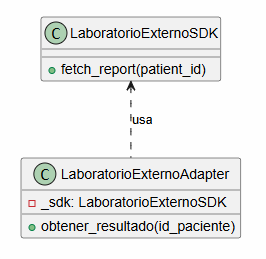

## Por qué Adapter y no otro patrón

Se consideró **Facade**, que también simplifica el acceso a un subsistema, pero Facade se usa para exponer una interfaz simplificada sobre **varias** clases relacionadas, mientras que aquí el problema es puntual: una sola clase externa con una interfaz incompatible que hay que encajar en un contrato ya existente (`obtener_resultado`). Adapter es la solución exacta para "traducir de una interfaz a otra sin tocar el código original", que es justo lo que exige integrar un SDK de terceros sin modificarlo.